In [26]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [27]:
# data from: https://www.kaggle.com/datasets/novandraanugrah/nasdaq-100-nas100-historical-price-data/data
# keep only 1m_data.csv
# rename 1m_data.csv -> NAS100_1min_ETH.csv

# Github link: https://github.com/Brianwu-bsa/SEM405_assignment

In [28]:
# prep_data.py
def preprocess_data(input_filepath, start_date):
    df = pd.read_csv(input_filepath, sep="\t")
    df.columns = df.columns.str.lower()

    df['datetime'] = pd.to_datetime(df['datetime'], format='%Y.%m.%d %H:%M:%S')
    # weird fix?????
    df['datetime'] = df['datetime'].dt.tz_localize('EET', ambiguous='NaT', nonexistent='shift_forward').dt.tz_convert('America/New_York')
    df.set_index('datetime', inplace=True)
    df = df.sort_index()

    df = df.loc[start_date:]
    df_rth = df.between_time("09:30", "16:00").copy()

    # ensure only valid sessions are left, server outages might occur
    daily_counts = df_rth.groupby(df_rth.index.normalize()).size()
    valid_dates = daily_counts[daily_counts >= 350].index
    df_rth = df_rth[df_rth.index.normalize().isin(valid_dates)]

    ohlc_cols = ['open', 'high', 'low', 'close']
    df_rth = df_rth[ohlc_cols].astype('float32')

    df_rth.to_csv('NAS100_1min_RTH.csv')
    df_rth.to_parquet('NAS100_1min_RTH.parquet')

    print(f"Processing complete!")
    print(f"Total RTH bars saved: {len(df_rth)}")

    return df_rth

In [29]:
# preprocess_data("NAS100_1min_ETH.csv", "2021-06-01")

In [30]:
# session.py

class Session:
    def __init__(self, file_path="NAS100_1min_RTH.parquet"):
        if file_path.endswith(".csv"):
            self.rth_df = pd.read_csv(file_path, index_col=0, dtype={'open': 'float32', 'high': 'float32', 'low': 'float32', 'close': 'float32'})
            self.rth_df.index = pd.to_datetime(self.rth_df.index, utc=True).tz_convert('America/New_York')
        elif file_path.endswith(".parquet"):
            self.rth_df = pd.read_parquet(file_path, engine="pyarrow")
        else:
            raise ValueError("File extension not supported!")
        self.sessions = [group for _, group in self.rth_df.groupby(self.rth_df.index.date)]
        self.dates = {index: date for index, (date, _) in enumerate(self.rth_df.groupby(self.rth_df.index.date))}

    def __len__(self):
        return len(self.sessions)

    def index_to_date(self, idx):
        date = self.dates.get(idx)
        if date is None:
            raise IndexError(f"Index not valid, might be under or over {len(self.sessions)}")
        return date

    def date_to_index(self, date: datetime.date):
        return list(self.dates.values()).index(date)  # O(N), not the time complexity I wanted but would have taken more mem complexity

    def get_dates(self):
        return list(self.dates.values())

    def get_session(self, idx):
        """
        :param idx:
        :return: A pandas dataframe of the open, low, high, close, volume from 9:30 to 16:00 EST
        """
        if idx >= len(self.sessions):
            raise IndexError(f"Index out of bounds, can only index up to less than {len(self.sessions)}")
        return self.sessions[idx]


In [31]:
# orb.py
from typing import Optional
from dataclasses import dataclass


@dataclass
class Trade:
    entry_time: pd.Timestamp
    entry_price: float
    direction: str  # long or short
    stop_loss: float
    take_profit: float
    orb_high: float
    orb_low: float
    orb_range: float

    exit_time: Optional[pd.Timestamp] = None
    exit_price: Optional[float] = None
    exit_reason: Optional[str] = None  # TP, SL, EOD (end of day)
    pnl_points: Optional[float] = None  # blended per-unit PnL
    pnl: Optional[float] = None # real pnl based on the set number of micro contracts
    result: Optional[str] = None  # "WIN" / "LOSS" (selling for 0 profit (breakeven) is considered a loss)

    market_return: Optional[float] = None

    def to_dict(self) -> dict:
        return {
            "entry_time": self.entry_time,
            "entry_price": self.entry_price,
            "direction": self.direction,
            "stop_loss": self.stop_loss,
            "take_profit": self.take_profit,
            "orb_high": self.orb_high,
            "orb_low": self.orb_low,
            "orb_range": self.orb_range,
            "exit_time": self.exit_time,
            "exit_price": self.exit_price,
            "exit_reason": self.exit_reason,
            "pnl_points": self.pnl_points,
            "pnl": self.pnl,
            "market_return": self.market_return,
            "result": self.result}


class ORB:
    def __init__(self, session: Session, micro_contracts=10):
        self.session = session

        self.RR = 2.50
        self.SL_factor = 1.00  # SL will be in the 100% of the range

        # each micro contract (MNQ) leveraged by 2x, for a fill mini-contract or (NQ) it's 20x leverage
        self.micro_contracts = micro_contracts

    def enter_trade(self, ts, open, low, high, close, orb_low, orb_high, direction: str) -> Trade:
        orb_range = orb_high - orb_low

        sl_distance = orb_range * self.SL_factor  # = 1.0 * range
        tp_distance = self.RR * sl_distance  # = 2.0 * range
        stop_loss = close - sl_distance * (1 if direction == "long" else -1)
        take_profit = close + tp_distance * (1 if direction == "long" else -1)

        return Trade(
            entry_time=ts,
            entry_price=close,
            direction=direction,
            stop_loss=stop_loss,
            orb_low=orb_low,
            orb_high=orb_high,
            orb_range=orb_range,
            take_profit=take_profit)

    def exit_trade(self, trade: Trade, exit_ts, exit_price, exit_reason):
        trade.exit_time = exit_ts
        trade.exit_reason = exit_reason

        if trade.direction == "long":
            trade.pnl_points = exit_price - trade.entry_price
            trade.pnl = trade.pnl_points * self.micro_contracts * 2
        else:
            trade.pnl_points = (trade.entry_price - exit_price)
            trade.pnl = trade.pnl_points * self.micro_contracts * 2

        if trade.pnl_points <= 0:
            trade.result = "LOSS"
        else:
            trade.result = "WIN"
        return trade

    def get_trade(self, df):
        orb_bars = df.between_time("9:30", "9:44")

        orb_high = max(orb_bars["high"])
        orb_low = min(orb_bars["low"])
        orb_range = orb_high - orb_low

        if not (20 <= orb_range <= 150):  # filter out orb ranges that are too small or too big
            return None

        forward_bars = df.between_time("9:45", "16:00")

        trade = None
        for ts, (open, high, low, close) in forward_bars.iterrows():
            if trade is None:  # find entry
                if close < orb_low:  # short
                    trade = self.enter_trade(ts, open, low, high, close, orb_low, orb_high, "short")
                elif close > orb_high:
                    trade = self.enter_trade(ts, open, low, high, close, orb_low, orb_high, "long")
            else:  # EOD exit
                if ts > ts.replace(hour=15, minute=55):
                    trade = self.exit_trade(trade, ts, close, exit_reason="EOD")
                    break

                if trade.direction == "long":
                    if low <= trade.stop_loss:
                        self.exit_trade(trade, ts, trade.stop_loss, "SL")
                        break
                    elif high >= trade.take_profit:
                        self.exit_trade(trade, ts, trade.take_profit, "TP")
                        break
                elif trade.direction == "short":
                    if high >= trade.stop_loss:
                        self.exit_trade(trade, ts, trade.stop_loss, "SL")
                        break
                    elif low <= trade.take_profit:
                        self.exit_trade(trade, ts, trade.take_profit, "TP")
                        break

        if trade is not None:
            if trade.exit_time is None:
                last_ts = forward_bars.index[-1]
                last_close = forward_bars['close'].iloc[-1]
                self.exit_trade(trade, last_ts, last_close, exit_reason="FORCE_CLOSE")
            trade.market_return = (df["close"].iloc[-1] - df["open"].iloc[0]) / df["open"].iloc[0]

        return trade

    def get_all_trades(self):
        trades = []
        for idx in range(len(self.session)):
            df = self.session.get_session(idx)
            trade = self.get_trade(df)
            if trade is not None:
                trades.append(trade)
        trades_df = pd.DataFrame([t.to_dict() for t in trades])
        return trades, trades_df


In [32]:
# create a session and get all the trades from the ORB
session = Session("NAS100_1min_RTH.csv")

# use parquet file for faster loading and operating
# session = Session("NAS100_1min_RTH.csv")

print("An example session:")
print(session.get_session(0).head())

orb = ORB(session, micro_contracts=10) # 10 micros = 1 mini (NQ)
trades, trades_df = orb.get_all_trades()

print("\nFirst trade:")
print(trades_df.iloc[0]) # get some information about the trades

An example session:
                                   open          high           low  \
datetime                                                              
2021-06-01 09:30:00-04:00  13757.000000  13765.000000  13750.299805   
2021-06-01 09:31:00-04:00  13758.000000  13760.299805  13753.000000   
2021-06-01 09:32:00-04:00  13756.000000  13756.299805  13748.000000   
2021-06-01 09:33:00-04:00  13751.299805  13753.299805  13745.500000   
2021-06-01 09:34:00-04:00  13752.299805  13755.799805  13749.299805   

                                  close  
datetime                                 
2021-06-01 09:30:00-04:00  13758.000000  
2021-06-01 09:31:00-04:00  13755.299805  
2021-06-01 09:32:00-04:00  13751.299805  
2021-06-01 09:33:00-04:00  13752.500000  
2021-06-01 09:34:00-04:00  13751.299805  

First trade:
entry_time       2021-06-01 09:48:00-04:00
entry_price                   13743.299805
direction                            short
stop_loss                     13775.099609
ta

In [33]:
print(f"Total Trades: {len(trades_df)}")
print(f"Wins: {len(trades_df[trades_df['result'] == 'WIN'])}")
print(f"Losses: {len(trades_df[trades_df['result'] == 'LOSS'])}")
print(f"Win Rate: {round(100 * len(trades_df[trades_df['result'] == 'WIN']) / len(trades_df), 2)}")
print(f"Total PnL (points): {round(trades_df['pnl_points'].sum(), 2)} pts")
print(f"Total PnL: {round(trades_df['pnl_points'].sum() * 20, 2)} dollars")
print(f"Avg PnL/Trade: {round(trades_df['pnl_points'].mean(), 2)} pts")
print(f"Best Trade: {round(trades_df['pnl_points'].max(), 2)} pts")
print(f"Worst Trade: {round(trades_df['pnl_points'].min(), 2)} pts")

Total Trades: 1014
Wins: 424
Losses: 590
Win Rate: 41.81
Total PnL (points): 9534.67 pts
Total PnL: 190693.3 dollars
Avg PnL/Trade: 9.4 pts
Best Trade: 365.25 pts
Worst Trade: -149.3 pts


In [34]:
# plot_equity.py
def plot_equity_curve(trades_df, mode="pnl_points"):
    cumulative_pnl = trades_df[mode].cumsum()  # calc the cumulative PNL
    trade_numbers = range(1, len(cumulative_pnl) + 1)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the equity curve
    ax.plot(trade_numbers, cumulative_pnl, marker='o', linestyle='-', color='royalblue', markersize=4,
            label=f"Cumulative PnL {'points' if mode == 'pnl_points' else ''}")

    # add horizontal line at zero for reference
    ax.axhline(0, color='black', linewidth=1, linestyle='--')

    # Add the area between the line and zero to highlight drawdowns vs profits
    ax.fill_between(trade_numbers, cumulative_pnl, 0, where=(cumulative_pnl >= 0), color='green', alpha=0.1)
    ax.fill_between(trade_numbers, cumulative_pnl, 0, where=(cumulative_pnl < 0), color='red', alpha=0.1)

    title = f"Equity Curve: Cumulative PnL {'points ' if mode == 'pnl_points' else ''}over Number of Trades"
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Trade Number", fontsize=12)
    ax.set_ylabel(f"Total PnL {'(Points)' if mode == 'pnl_points' else ''}", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

    plt.tight_layout()
    # plt.savefig(f"Equity_curve_pnl{'_points' if mode == 'pnl_points' else ''}.png")
    plt.show()

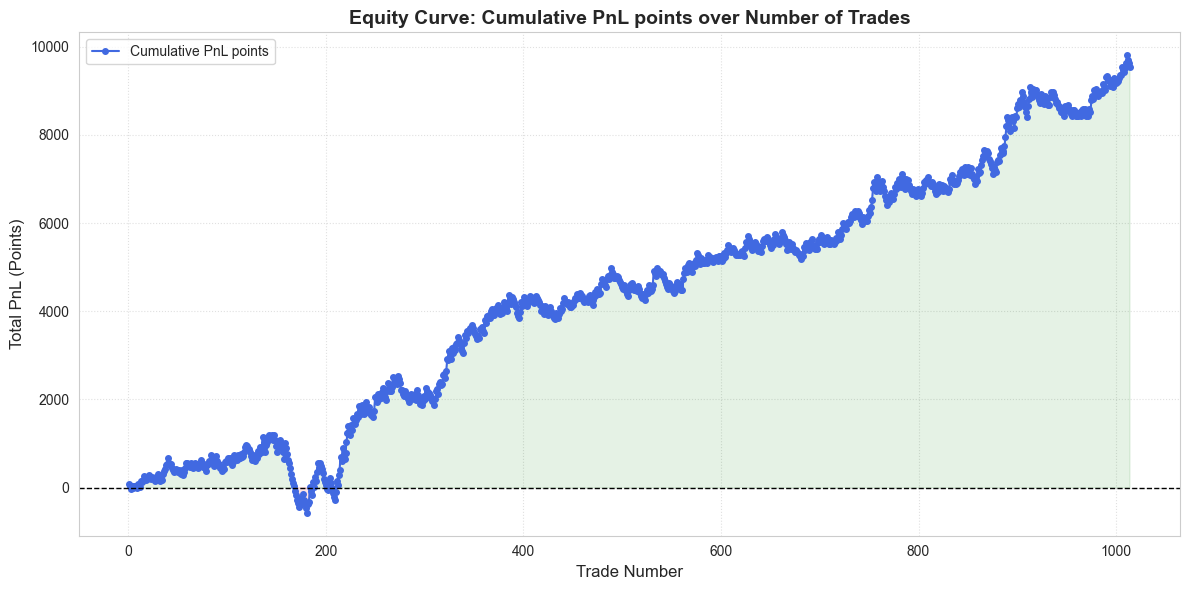

In [35]:
plot_equity_curve(trades_df, mode="pnl_points") # raw pnl points graph

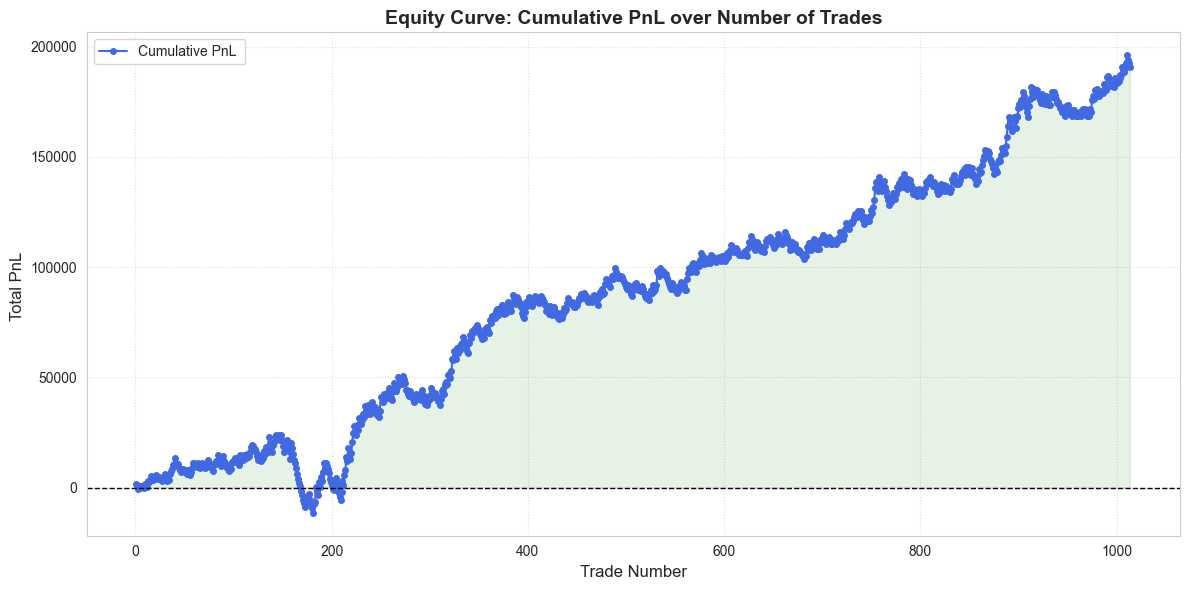

In [36]:
plot_equity_curve(trades_df, mode="pnl") # raw pnl dollars graph


===== MANUAL CHECK =====
Manual Mean: 9.4
Pandas Mean: 9.4
Manual Median: -37.95
Pandas Median: -37.95
Number of trades used for analysis: 1014
Full Data Mean: 9.4
Full Data Median: -37.95


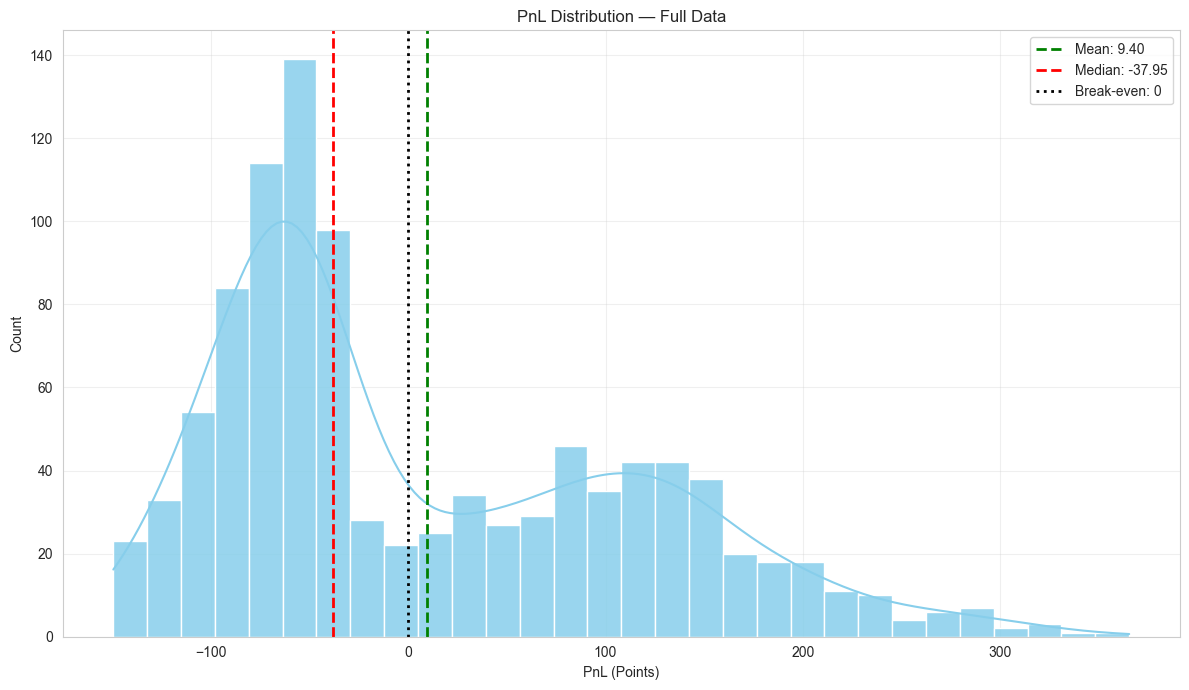

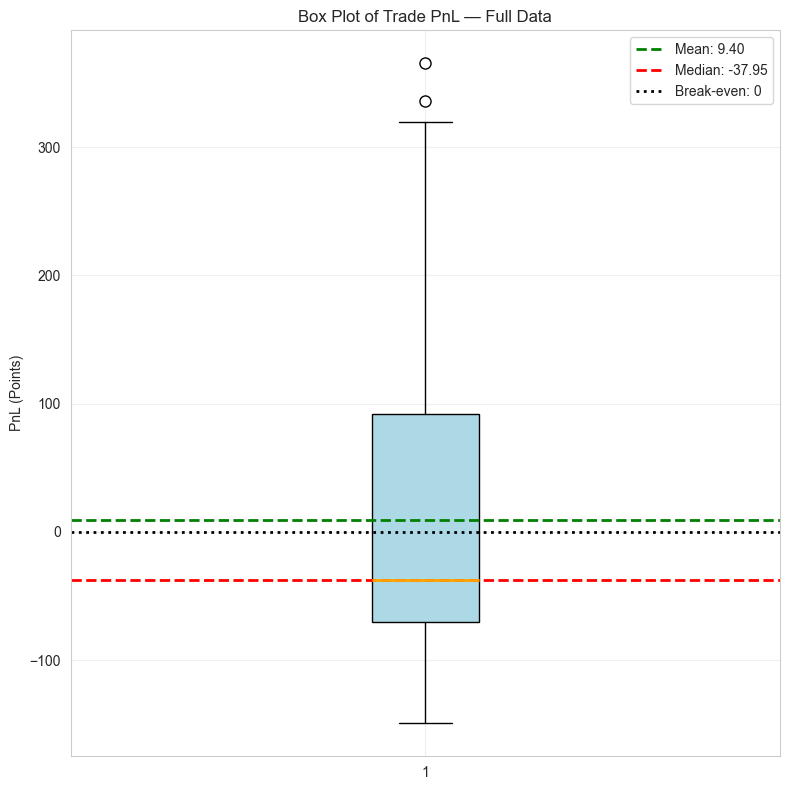


10% Sample size: 101
Sample Mean: 2.06
Sample Median: -43.5


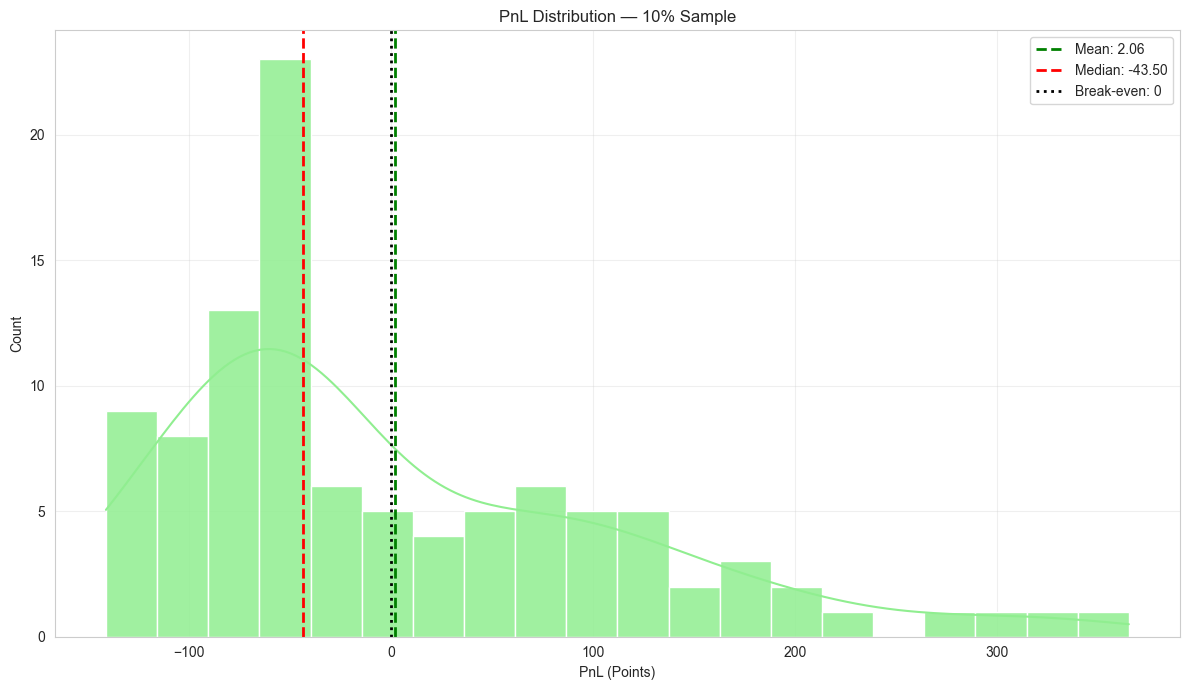

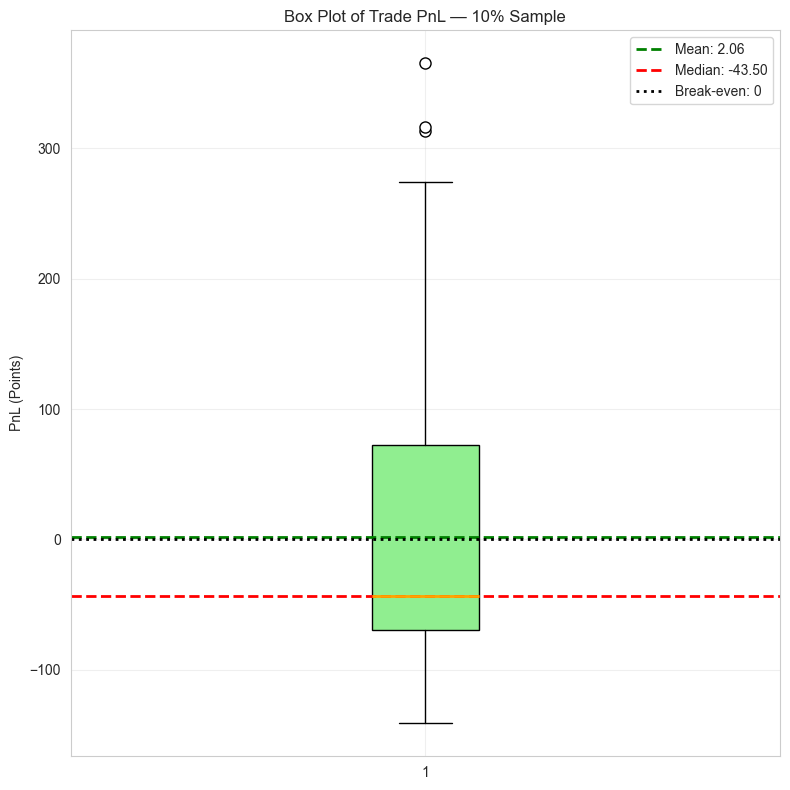

In [37]:
# Farhan/graph.py

# Main analysis column
pnl = trades_df["pnl_points"].dropna()

print("\n===== MANUAL CHECK =====")

# Convert to list
pnl_list = pnl.tolist()

# Sort for median
sorted_pnl = sorted(pnl_list)

n = len(sorted_pnl)

# Manual median
if n % 2 == 0:
    manual_median = (sorted_pnl[n//2 - 1] + sorted_pnl[n//2]) / 2
else:
    manual_median = sorted_pnl[n//2]

# Manual mean
manual_mean = sum(pnl_list) / n

print("Manual Mean:", round(manual_mean, 2))
print("Pandas Mean:", round(pnl.mean(), 2))

print("Manual Median:", round(manual_median, 2))
print("Pandas Median:", round(pnl.median(), 2))

# ---------------- FULL DATA ----------------
mean_pnl = pnl.mean()
median_pnl = pnl.median()

print("Number of trades used for analysis:", len(pnl))
print("Full Data Mean:", round(mean_pnl, 2))
print("Full Data Median:", round(median_pnl, 2))

# Full data histogram
plt.figure(figsize=(12, 7))
sns.histplot(pnl, bins=30, kde=True, color="skyblue", edgecolor="white", alpha=0.85)
plt.axvline(mean_pnl, color="green", linestyle="--", linewidth=2, label=f"Mean: {mean_pnl:.2f}")
plt.axvline(median_pnl, color="red", linestyle="--", linewidth=2, label=f"Median: {median_pnl:.2f}")
plt.axvline(0, color="black", linestyle=":", linewidth=2, label="Break-even: 0")
plt.title("PnL Distribution — Full Data")
plt.xlabel("PnL (Points)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("histogram_full.png", dpi=300)
plt.show()

# Full data box plot
plt.figure(figsize=(8, 8))
plt.boxplot(
    pnl,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="orange", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=8),
)
plt.axhline(mean_pnl, color="green", linestyle="--", linewidth=2, label=f"Mean: {mean_pnl:.2f}")
plt.axhline(median_pnl, color="red", linestyle="--", linewidth=2, label=f"Median: {median_pnl:.2f}")
plt.axhline(0, color="black", linestyle=":", linewidth=2, label="Break-even: 0")
plt.title("Box Plot of Trade PnL — Full Data")
plt.ylabel("PnL (Points)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("boxplot_full.png", dpi=300)
plt.show()

# ---------------- 10% SAMPLE ----------------
sample = pnl.sample(frac=0.1, random_state=42)
sample_mean = sample.mean()
sample_median = sample.median()

print("\n10% Sample size:", len(sample))
print("Sample Mean:", round(sample_mean, 2))
print("Sample Median:", round(sample_median, 2))

# Sample histogram
plt.figure(figsize=(12, 7))
sns.histplot(sample, bins=20, kde=True, color="lightgreen", edgecolor="white", alpha=0.85)
plt.axvline(sample_mean, color="green", linestyle="--", linewidth=2, label=f"Mean: {sample_mean:.2f}")
plt.axvline(sample_median, color="red", linestyle="--", linewidth=2, label=f"Median: {sample_median:.2f}")
plt.axvline(0, color="black", linestyle=":", linewidth=2, label="Break-even: 0")
plt.title("PnL Distribution — 10% Sample")
plt.xlabel("PnL (Points)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("histogram_sample.png", dpi=300)
plt.show()

# Sample box plot
plt.figure(figsize=(8, 8))
plt.boxplot(
    sample,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen", color="black"),
    medianprops=dict(color="orange", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=8),
)
plt.axhline(sample_mean, color="green", linestyle="--", linewidth=2, label=f"Mean: {sample_mean:.2f}")
plt.axhline(sample_median, color="red", linestyle="--", linewidth=2, label=f"Median: {sample_median:.2f}")
plt.axhline(0, color="black", linestyle=":", linewidth=2, label="Break-even: 0")
plt.title("Box Plot of Trade PnL — 10% Sample")
plt.ylabel("PnL (Points)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("boxplot_sample.png", dpi=300)
plt.show()

In [38]:
# Mirac/descriptve_stats.py

from scipy import stats as sp_stats
from collections import Counter

def compute_trimmed_mean(data: np.ndarray, trim_pct: float) -> float:
    """
    Computes a trimmed mean by removing the lowest and highest
    *trim_pct* fraction of values before averaging.
    For example trim_pct = 0.01 removes the bottom 1 % and the top 1 %.
    """
    return float(sp_stats.trim_mean(data, trim_pct))


def compute_mode(data: np.ndarray) -> float:
    """
    Finds the most frequently occurring value.
    Because PnL values are continuous floats, we round to 2 decimal
    places first so that nearly identical values are grouped together.
    If there are multiple modes, we return the smallest one.
    """
    rounded = np.round(data, 2)
    counts = Counter(rounded)
    max_count = max(counts.values())
    modes = sorted(val for val, cnt in counts.items() if cnt == max_count)
    return float(modes[0])


def compute_percentiles(data: np.ndarray) -> dict:
    """
    Computes a set of standard percentiles and the inter-quartile range.
    Percentiles are calculated using linear interpolation (NumPy default).
    """
    pct_keys = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    percentiles = {f"P{p}": float(np.percentile(data, p)) for p in pct_keys}

    # Quartiles are just specific percentiles; we label them explicitly
    percentiles["Q1"] = percentiles["P25"]
    percentiles["Q2"] = percentiles["P50"]
    percentiles["Q3"] = percentiles["P75"]
    percentiles["IQR"] = percentiles["Q3"] - percentiles["Q1"]
    return percentiles


def compute_all_stats(data: np.ndarray, label: str = "Full Data") -> dict:
    """
    Runs all descriptive statistics on a given array of PnL values
    and returns them as a tidy dictionary.
    """
    results = {
        "label": label,
        "n": len(data),
        "mean": float(np.mean(data)),
        "median": float(np.median(data)),
        "mode": compute_mode(data),
        "range": np.max(data) - np.min(data),
        "min": np.min(data),
        "max": np.max(data),
        "trimmed_mean_1pct": compute_trimmed_mean(data, 0.01),
        "trimmed_mean_2_5pct": compute_trimmed_mean(data, 0.025),
        "variance": float(np.var(data, ddof=1)),       # sample variance (N-1)
        "std_dev": float(np.std(data, ddof=1)),         # sample std dev  (N-1)
    }
    results.update(compute_percentiles(data))
    return results


# ── Pretty-printer ───────────────────────────────────────────────────────────

SEPARATOR = "─" * 60

def print_section(title: str):
    """Prints a clearly visible section header."""
    print(f"\n{SEPARATOR}")
    print(f"  {title}")
    print(SEPARATOR)


def print_stats(s: dict):
    """Prints the statistics dictionary in a readable table format."""
    print_section(s["label"])
    print(f"  Number of trades        : {s['n']}")
    print()
    print(f"  Mean                    : {s['mean']:>10.2f} pts")
    print(f"  Median                  : {s['median']:>10.2f} pts")
    print(f"  Mode                    : {s['mode']:>10.2f} pts")
    print(f"  Range                   : {s['range']:>10.2f} pts")
    print(f"  Min                     : {s['min']:>10.2f} pts")
    print(f"  Max                     : {s['max']:>10.2f} pts")
    print(f"  Trimmed Mean (1 %)      : {s['trimmed_mean_1pct']:>10.2f} pts")
    print(f"  Trimmed Mean (2.5 %)    : {s['trimmed_mean_2_5pct']:>10.2f} pts")
    print()
    print(f"  Variance                : {s['variance']:>10.2f}")
    print(f"  Standard Deviation      : {s['std_dev']:>10.2f} pts")
    print()
    print(f"  P1                      : {s['P1']:>10.2f} pts")
    print(f"  P5                      : {s['P5']:>10.2f} pts")
    print(f"  P10                     : {s['P10']:>10.2f} pts")
    print(f"  Q1  (25th percentile)   : {s['Q1']:>10.2f} pts")
    print(f"  Q2  (50th / median)     : {s['Q2']:>10.2f} pts")
    print(f"  Q3  (75th percentile)   : {s['Q3']:>10.2f} pts")
    print(f"  P90                     : {s['P90']:>10.2f} pts")
    print(f"  P95                     : {s['P95']:>10.2f} pts")
    print(f"  P99                     : {s['P99']:>10.2f} pts")
    print(f"  IQR (Q3 − Q1)           : {s['IQR']:>10.2f} pts")


def print_comparison(full: dict, sample: dict):
    """
    Prints a side-by-side comparison between the full dataset and the
    10 % subsample so we can visually evaluate whether the edge persists.
    """
    print_section("Comparison — Full Data vs. 10 % Subsample")

    header = f"  {'Metric':<26} {'Full':>10}   {'Sample':>10}   {'Delta':>10}"
    print(header)
    print("  " + "─" * 56)

    keys = [
        ("Mean",                "mean"),
        ("Median",              "median"),
        ("Mode",                "mode"),
        ("Range",               "range"),
        ("Min",               "min"),
        ("Max",               "max"),
        ("Trimmed Mean 1 %",    "trimmed_mean_1pct"),
        ("Trimmed Mean 2.5 %",  "trimmed_mean_2_5pct"),
        ("Std Dev",             "std_dev"),
        ("Q1",                  "Q1"),
        ("Q3",                  "Q3"),
        ("IQR",                 "IQR"),
    ]
    for label, key in keys:
        f_val = full[key]
        s_val = sample[key]
        delta = s_val - f_val
        print(f"  {label:<26} {f_val:>10.2f}   {s_val:>10.2f}   {delta:>+10.2f}")

    # Check whether the subsample still has a positive mean PnL (i.e. edge holds)
    print()
    if sample["mean"] > 0:
        print("  ✓  Subsample mean is positive — the edge holds in the 10 % draw.")
    else:
        print("  ✗  Subsample mean is non-positive — the edge may not be robust.")

    # Show that Q1 is smaller than Q3 demonstrating asymmetric risk/reward
    if full["Q1"] < full["Q3"] and abs(full["Q3"]) > abs(full["Q1"]):
        print("  ✓  |Q3| > |Q1| — asymmetric risk-to-reward confirmed (more upside).")
    else:
        print("  ⚠  Q1/Q3 relationship does not show clear asymmetric reward.")


# ── Charts ───────────────────────────────────────────────────────────────────

def plot_percentile_bar(stats: dict, filename: str):
    """
    Horizontal bar chart of all nine percentiles.
    This gives a quick visual overview of the PnL distribution's shape —
    if the right side stretches further than the left, the reward
    is asymmetric relative to the risk.
    """
    labels = ["P1", "P5", "P10", "Q1", "Q2 (Median)", "Q3", "P90", "P95", "P99"]
    keys   = ["P1", "P5", "P10", "Q1", "Q2",           "Q3", "P90", "P95", "P99"]
    values = [stats[k] for k in keys]

    colours = ["#e74c3c" if v < 0 else "#2ecc71" for v in values]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels, values, color=colours, edgecolor="white", height=0.6)
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_xlabel("PnL (Points)")
    ax.set_title(f"Percentile Breakdown — {stats['label']}")
    ax.grid(axis="x", alpha=0.3)

    # Put value labels on each bar
    for bar, val in zip(bars, values):
        x_pos = val + (3 if val >= 0 else -3)
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}", va="center",
                ha="left" if val >= 0 else "right",
                fontsize=9, fontweight="bold")

    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.close(fig)
    print(f"  → Saved: {filename}")


def plot_comparison_grouped_bar(full: dict, sample: dict, filename: str):
    """
    Grouped bar chart that puts Full vs. Sample side by side for the
    key summary statistics so the viewer can compare at a glance.
    """
    labels = ["Mean", "Median", "Mode", "Trim 1%", "Trim 2.5%",
              "Std Dev", "Q1", "Q3", "IQR"]
    keys   = ["mean", "median", "mode", "trimmed_mean_1pct",
              "trimmed_mean_2_5pct", "std_dev", "Q1", "Q3", "IQR"]

    full_vals   = [full[k] for k in keys]
    sample_vals = [sample[k] for k in keys]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - width / 2, full_vals,   width, label="Full Data",
           color="#3498db", edgecolor="white")
    ax.bar(x + width / 2, sample_vals, width, label="10 % Sample",
           color="#e67e22", edgecolor="white")

    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("PnL (Points)")
    ax.set_title("Full Data vs. 10 % Subsample — Key Statistics")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.close(fig)
    print(f"  → Saved: {filename}")


def main():
    # Load the 1-minute NQ data and generate all ORB trades
    session = Session("NAS100_1min_RTH.parquet")
    orb = ORB(session)
    trades, df = orb.get_all_trades()

    # Build a DataFrame and extract the PnL column, dropping any None values
    pnl = df["pnl_points"].dropna()

    # ── Full dataset analysis ────────────────────────────────────────────
    full_stats = compute_all_stats(pnl.values, label="Full Data — All Trades")
    print_stats(full_stats)

    # ── 10 % random subsample ───────────────────────────────────────────
    # We use a fixed seed so the results are reproducible across runs
    pnl_sample = pnl.sample(frac=0.1, random_state=42)

    sample_stats = compute_all_stats(pnl_sample, label="10 % Subsample")
    print_stats(sample_stats)

    # ── Side-by-side comparison ─────────────────────────────────────────
    print_comparison(full_stats, sample_stats)

    # ── Generate charts ─────────────────────────────────────────────────
    print_section("Charts")
    plot_percentile_bar(full_stats, "percentiles_full.png")
    plot_percentile_bar(sample_stats, "percentiles_sample.png")
    plot_comparison_grouped_bar(full_stats, sample_stats, "comparison_full_vs_sample.png")

    print(f"\n{SEPARATOR}")
    print("  Analysis complete.")
    print(SEPARATOR)

    print_stats(full_stats)
    print_stats(sample_stats)
    print_comparison(full_stats, sample_stats)


In [39]:
main()


────────────────────────────────────────────────────────────
  Full Data — All Trades
────────────────────────────────────────────────────────────
  Number of trades        : 1014

  Mean                    :       9.40 pts
  Median                  :     -37.95 pts
  Mode                    :     -86.20 pts
  Range                   :     514.55 pts
  Min                     :    -149.30 pts
  Max                     :     365.25 pts
  Trimmed Mean (1 %)      :       7.88 pts
  Trimmed Mean (2.5 %)    :       6.05 pts

  Variance                :   11215.39
  Standard Deviation      :     105.90 pts

  P1                      :    -140.94 pts
  P5                      :    -117.67 pts
  P10                     :     -99.55 pts
  Q1  (25th percentile)   :     -70.37 pts
  Q2  (50th / median)     :     -37.95 pts
  Q3  (75th percentile)   :      92.10 pts
  P90                     :     158.00 pts
  P95                     :     204.84 pts
  P99                     :     288.79 pts
  I

In [40]:
# Brian's stuff from here on out

In [41]:
from scipy import stats

In [42]:
# Brian/CI.py
def compute_confidence_interval(trades_df, CI=0.95):
    pnl = trades_df["pnl_points"]
    mean = pnl.mean()
    SE = stats.sem(pnl)  # standard error
    return stats.t.interval(CI, df=len(pnl) - 1, loc=mean, scale=SE)  # df here is degrees of freedom

In [43]:
for CI in [0.75, 0.85, 0.95, 0.99]:
    CIL, CIU = compute_confidence_interval(trades_df, CI)
    print(f"{CI * 100}% confidence interval: {CIL, CIU} points")

75.0% confidence interval: (5.575065754620509, 13.23097968731736) points
85.0% confidence interval: (4.6118836676675485, 14.19416177427032) points
95.0% confidence interval: (2.8768960778376194, 15.92914936410025) points
99.0% confidence interval: (0.8203160782356491, 17.98572936370222) points


In [44]:
from statsmodels.stats.weightstats import ztest

In [45]:
# Brian/t_test.py
def t_test(trades_df):
    pnl_points = trades_df["pnl_points"]
    t_stat, p_value = stats.ttest_1samp(pnl_points, popmean=0, alternative="greater")

    return t_stat, p_value

def z_test(trades_df):
    pnl_points = trades_df["pnl_points"]
    z_stat, p_value = ztest(pnl_points, value=0, alternative="larger")
    return z_stat, p_value

In [46]:
# H0: u <=0 
# H1: u > 0 (as in there is an edge, and thus profitable)
print(f"t-test, (t-stat, p-value):", t_test(trades_df))
print(f"z-test, (z-stat, p-value):", z_test(trades_df))
print("-" * 35)

t_stat, p_value = t_test(trades_df)
print(f"t-stat of: {round(t_stat, 4)} and a p-value of: {round(p_value, 6)}.")
if p_value < 0.05:
    print("H0: u <= 0, is rejected. Results are statistically significant, thus H1: u > 0")
else:
    print("H0: u <=0  is not rejected. Results have no statistical significance.")

t-test, (t-stat, p-value): (2.82734813943698, 0.0023929780012724657)
z-test, (z-stat, p-value): (2.82734813943698, 0.0023467635507244205)
-----------------------------------
t-stat of: 2.8273 and a p-value of: 0.002393.
H0: u <= 0, is rejected. Results are statistically significant, thus H1: u > 0


In [47]:
# Brian/alpha_beta.py
def compute_alpha_beta(trades_df):
    market_return = trades_df["market_return"]  # X
    strategy_return = trades_df["pnl_points"] / trades_df["entry_price"]  # y
    result = stats.linregress(market_return, strategy_return)
    result = {"slope": result.slope,
              "intercept": result.intercept,
              "r_value": result.rvalue,
              "r_squared": result.rvalue ** 2,
              "p_value": result.pvalue,
              "annualized_alpha": ((1 + result.intercept) ** 252 - 1)}
    return result

def compute_levered_alpha_beta(trades_df, account_value=50000):
    market_return = trades_df["market_return"]  # X
    strategy_return = trades_df["pnl"] / account_value  # y
    result = stats.linregress(market_return, strategy_return)
    result = {"slope": result.slope,
              "intercept": result.intercept,
              "r_value": result.rvalue,
              "r_squared": result.rvalue ** 2,
              "p_value": result.pvalue,
              "annualized_alpha": ((1 + result.intercept) ** 252 - 1)}
    return result

def print_result(result):
    beta = result["slope"]
    alpha = result["intercept"] 
    r_value = result["r_value"] # rvalue is the correlation coefficient (R)
    r_squared = result["r_squared"] # rvalue is the correlation coefficient (R)
    p_value = result["p_value"]  # p-value for the hypothesis test on Beta
    annualized_alpha = result["annualized_alpha"]

    print(f"Beta (Market Exposure): {round(beta, 4)}")
    print(f"Alpha (Excess Return): {round(alpha, 6)} (Per Trade/Day)")
    print(f"Alpha (Excess Return): {round(annualized_alpha, 6)} (Annualized)")
    print(f"R-value: {round(r_value, 4)}")
    print(f"R-squared (Determination): {round(r_squared, 4)}")
    print(f"P-value (Beta significance): {round(p_value, 4)}")

def plot_returns(trades_df, result):
    market_return = trades_df["market_return"]
    strategy_return = trades_df["pnl_points"] / trades_df["entry_price"]

    regression_line = result["intercept"] + result["slope"] * market_return

    # Initialize the figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the scatter points of the actual daily returns
    ax.scatter(market_return, strategy_return, alpha=0.5, color='cyan', edgecolor='black', label='Daily Returns')

    # Plot the linear regression line
    ax.plot(market_return, regression_line, color='red', linewidth=2,
            label=f'Regression Line ($y = {round(result["slope"], 4)}x + {round(result["intercept"], 6)}$)')

    # Formatting and Labels
    ax.set_title("15m ORB Strategy Return vs. NAS100 Market Return", fontsize=14, fontweight='bold')
    ax.set_xlabel("Market Return (RTH Close - Open) / Open", fontsize=12)
    ax.set_ylabel("Strategy Return (Unlevered)", fontsize=12)

    # Add horizontal and vertical lines at 0 to clearly divide the 4 performance quadrants
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.axvline(0, color='black', linewidth=1, linestyle='--')

    # Create a text box to display the statistical results directly on the chart
    stats_text = (
        f"$\\beta$ (Beta): {round(result["slope"], 4)}\n"
        f"$\\alpha$ (Alpha): {round(result["intercept"], 6)}\n"
        f"$\\alpha$ (Annualized Alpha): {round(result["annualized_alpha"] * 100, 2)}%\n"
        f"$r$: {round(result["r_value"], 4)}\n"
        f"$R^2$: {round(result["r_squared"], 4)}\n"
        f"p-value: {round(result["p_value"], 4)}"
    )

    # Place the text box in the upper left corner
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    # Add grid and legend
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right')

    # plt.savefig("returns.png")

    plt.tight_layout()
    plt.show()


def plot_levered_returns(trades_df, result, account_value=50000):
    market_return = trades_df["market_return"]
    strategy_return = trades_df["pnl"] / account_value

    regression_line = result["intercept"] + result["slope"] * market_return

    # Initialize the figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the scatter points of the actual daily returns
    ax.scatter(market_return, strategy_return, alpha=0.75, color='deepskyblue', edgecolor='black', label='Daily Returns')

    # Plot the linear regression line
    ax.plot(market_return, regression_line, color='red', linewidth=2,
            label=f'Regression Line ($y = {round(result["slope"], 4)}x + {round(result["intercept"], 6)}$)')

    # Formatting and Labels
    ax.set_title("15m ORB Strategy Return (Levered 20x) vs. NAS100 Market Return", fontsize=14, fontweight='bold')
    ax.set_xlabel("Market Return (RTH Close - Open) / Open", fontsize=12)
    ax.set_ylabel("Strategy Return (Levered)", fontsize=12)

    # Add horizontal and vertical lines at 0 to clearly divide the 4 performance quadrants
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.axvline(0, color='black', linewidth=1, linestyle='--')

    # Create a text box to display the statistical results directly on the chart
    stats_text = (
        f"$\\beta$ (Beta): {round(result["slope"], 4)}\n"
        f"$\\alpha$ (Alpha): {round(result["intercept"], 6)}\n"
        f"$\\alpha$ (Annualized Alpha): {round(result["annualized_alpha"] * 100, 2)}%\n"
        f"$r$: {round(result["r_value"], 4)}\n"
        f"$R^2$: {round(result["r_squared"], 4)}\n"
        f"p-value: {round(result["p_value"], 4)}"
    )

    # Place the text box in the upper left corner
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    # Add grid and legend
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right')

    # plt.savefig("levered_returns.png")

    plt.tight_layout()
    plt.show()

--- Linear Regression Results (Strategy vs Market) Unlevered ---
Beta (Market Exposure): -0.0134
Alpha (Excess Return): 0.000623 (Per Trade/Day)
Alpha (Excess Return): 0.169836 (Annualized)
R-value: -0.0211
R-squared (Determination): 0.0004
P-value (Beta significance): 0.5019


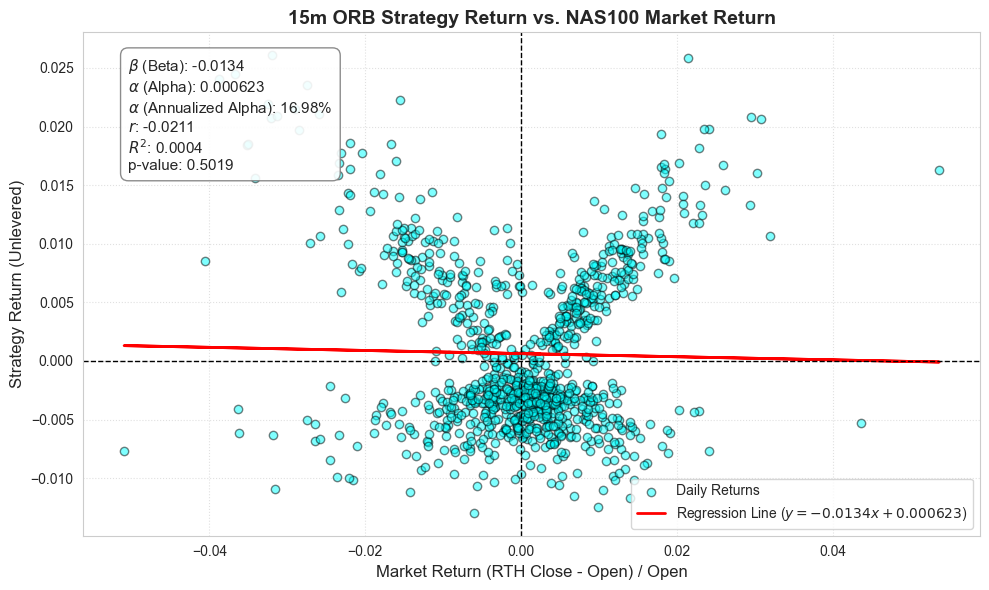

--- Linear Regression Results (Strategy vs Market) Levered ---
Beta (Market Exposure): -0.1182
Alpha (Excess Return): 0.003785 (Per Trade/Day)
Alpha (Excess Return): 1.590658 (Annualized)
R-value: -0.0309
R-squared (Determination): 0.001
P-value (Beta significance): 0.3255


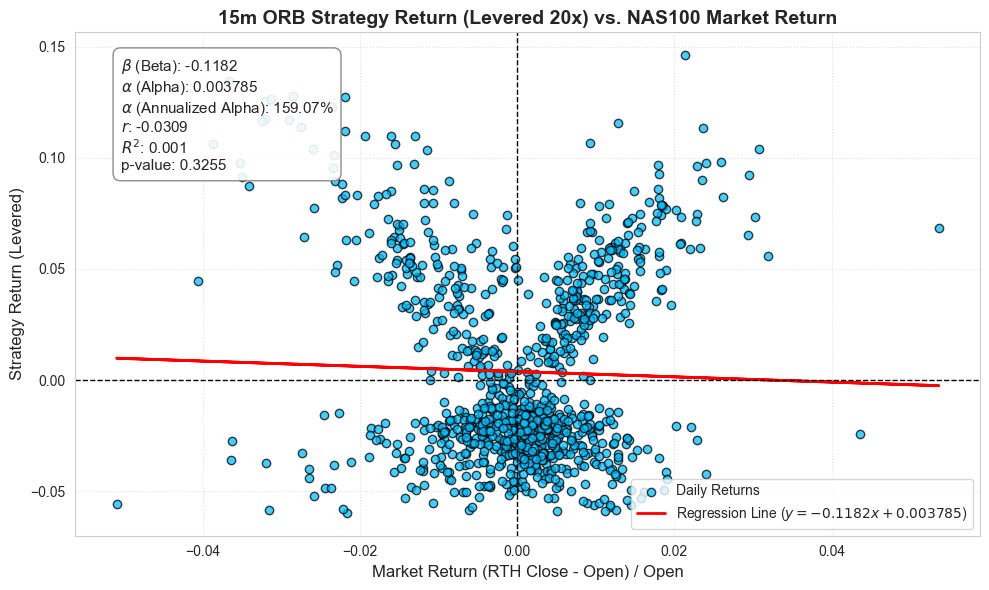

In [48]:
print("--- Linear Regression Results (Strategy vs Market) Unlevered ---")
result = compute_alpha_beta(trades_df)
print_result(result)
plot_returns(trades_df, result)

print("--- Linear Regression Results (Strategy vs Market) Levered ---")
result = compute_levered_alpha_beta(trades_df)
print_result(result)
plot_levered_returns(trades_df, result)

In [48]:
# author for compiling: Brian